# **Business Case 1: Segmenting Clients**
<br>

## Goal

Here we have a random extraction of **a (real-world) dataset made up of a bank's customers**. The data is **anonymous, mostly clean and normalized in [0, 1]**.

We intend to **segment these customers using Data Science techniques** (essentially Unsupervised Machine Learning); this is a segmentation carried out from the perspective of the financial services sector.


The **dataset is called "Dataset1_BankClients"** and is saved as a .xls file.

<br>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler

import Utilities



In [2]:
# Load data in a DataFrame
path = "./Dataset1_BankClients.xlsx"
data = pd.read_excel(path)
data = data.drop(columns=['ID'])  # Replace 'ID' with the actual column name to drop
data.head()


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


# Preparing data

### Data cleaning

Since the data is a  mix of **Numerical** and **Categorical** we need to find a proper measure to make them standard.


We have to:
* **Encode categorical variables**, so that they can be digestible by clustering algorithms - they are all trasformed in boolean variables by one-hot encoding.
* **Normalize** in [0, 1] numerical variables.

### Business Lens Analysis

Features are grouped into three business lenses capturing different aspects of the client's financial profile.

**Lens 1: Financial Capacity & Stress ("The Wallet")**
Focuses on hard financial indicators — what the client earns, owns, and owes.
Features: Income (annual earnings), Wealth (total assets), Debt (total liabilities).

**Lens 2: Bank Engagement & Literacy ("The Relationship")**
Captures how the client interacts with the financial system and the bank.
Features: FinEdu (financial education), Digital (digital adoption), BankFriend (relationship strength).

**Lens 3: Spending & Behavioral Persona ("The Choices")**
Reflects how the client allocates and uses their money.
Features: Lifestyle, Luxury, Saving, Investments, ESG.

#### Behavioral Clustering and Demographic Profiling

Clustering is performed exclusively on the **behavioral dimensions represented by the three lenses**, allowing the model to identify groups of clients who share similar financial habits and decision patterns.

**Demographic variables (e.g., Age, Gender, Job, Area, CitySize)** are not included in the clustering process. Incorporating them directly would risk forming clusters driven by location or occupation rather than genuine financial behavior.

Instead, demographics are used **after clustering** to profile and interpret the discovered personas.
For example, once a behavioral segment such as *“Aggressive Digital Investors”* emerges, demographic variables help answer questions like **where these clients tend to live, what jobs they hold, or what age groups they belong to**.

This separation ensures that clusters reflect **true behavioral patterns**, while demographics provide **context for business interpretation and strategy**.

### Distance measure

<br>

**First of all we need a proper distance** there are many distances - [Comprehensive Survey on Distance/Similarity Measures between Probability Density Functions](http://www.fisica.edu.uy/~cris/teaching/Cha_pdf_distances_2007.pdf): a suitable one is the **Gower's distance**, because it is specifically designed for mixed categorical and numerical data.

The Gower distance is the **average of all individual feature distances**. Nothing special: it ensures that each feature contributes proportionally, preventing any one type from dominating.

<br>



In [3]:
# DATA CLEANING & OUTLIER REMOVAL
CATEGORICAL_COLS = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
CONTINUOUS_COLS  = [col for col in data.columns if col not in CATEGORICAL_COLS]

data = Utilities.find_outliers_selective(data, CONTINUOUS_COLS)

# DEFINE LENSES & DEMOGRAPHICS

LENS_COLS = {
    'lens1': ['Income', 'Wealth', 'Debt'],
    'lens2': ['FinEdu', 'Digital', 'BankFriend'],
    'lens3': ['LifeStyle', 'Luxury', 'Investments', 'Saving', 'ESG'],
}
DEMO_COLS = ['Age', 'Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

LENS3_ORDINAL_COLS = ['Investments']
LENS3_CONT_COLS    = [c for c in LENS_COLS['lens3'] if c not in LENS3_ORDINAL_COLS]

# SPLIT & CAST

df_lens1 = data[LENS_COLS['lens1']].copy()
df_lens2 = data[LENS_COLS['lens2']].copy()
df_lens3 = data[LENS_COLS['lens3']].copy()
df_demo  = data[DEMO_COLS].copy()

# Keep Investments as int — ordinal distance respects 1 < 2 < 3
df_lens3[LENS3_ORDINAL_COLS] = df_lens3[LENS3_ORDINAL_COLS].astype(int)

# NORMALIZE — each lens gets its own scaler ──────────────────────────────

df_lens1_norm = Utilities.normalize_df(df_lens1, MinMaxScaler())
df_lens2_norm = Utilities.normalize_df(df_lens2, MinMaxScaler())
df_lens3_norm = Utilities.normalize_df(df_lens3, MinMaxScaler())

# COMPUTE DISTANCE MATRICES ──────────────────────────────────────────────

best_k1, weights1, score1, dist_mat_lens1 = Utilities.build_lens_distance(
    df_lens1_norm, cont_cols=LENS_COLS['lens1']
)
best_k2, weights2, score2, dist_mat_lens2 = Utilities.build_lens_distance(
    df_lens2_norm, cont_cols=LENS_COLS['lens2']
)
best_k3, weights3, score3, dist_mat_lens3 = Utilities.build_lens_distance(
    df_lens3_norm, cont_cols=LENS3_CONT_COLS, ordinal_cols=LENS3_ORDINAL_COLS
)

print("Data preprocessing complete. Distance matrices ready for clustering.")

Feature 'ESG' has 5 outliers.
Feature 'BankFriend' has 2 outliers.

Dropped 7 total rows.
Data preprocessing complete. Distance matrices ready for clustering.


In [4]:
print("=" * 50)
print("LENS 1 — Income / Wealth / Debt")
print(f"  Clusters   : {best_k1}")
print(f"  Silhouette : {score1:.4f}")

print("=" * 50)
print("LENS 2 — FinEdu / Digital / BankFriend")
print(f"  Clusters   : {best_k2}")
print(f"  Silhouette : {score2:.4f}")

print("=" * 50)
print("LENS 3 — LifeStyle / Luxury / Saving / ESG / Investments")
print(f"  Clusters         : {best_k3}")
print(f"  Silhouette       : {score3:.4f}")
print(f"  Continuous alpha : {weights3[0]:.3f}")
print(f"  Ordinal beta     : {weights3[1]:.3f}")
print("=" * 50)

LENS 1 — Income / Wealth / Debt
  Clusters   : 2
  Silhouette : 0.3384
LENS 2 — FinEdu / Digital / BankFriend
  Clusters   : 2
  Silhouette : 0.3494
LENS 3 — LifeStyle / Luxury / Saving / ESG / Investments
  Clusters         : 3
  Silhouette       : 0.7835
  Continuous alpha : 0.233
  Ordinal beta     : 0.500


In [5]:
#  CLUSTER EACH LENS INDEPENDENTLY (Using Agglomerative)
print("Running Agglomerative clustering on distance matrices...")

# linkage='average' works best with Gower distances
agg_lens1 = AgglomerativeClustering(n_clusters=best_k1, metric='precomputed', linkage='average')
agg_lens2 = AgglomerativeClustering(n_clusters=best_k2, metric='precomputed', linkage='average')
agg_lens3 = AgglomerativeClustering(n_clusters=best_k3, metric='precomputed', linkage='average')

# Fit the models and extract the cluster labels (0, 1, or 2)
labels_lens1 = agg_lens1.fit_predict(dist_mat_lens1)
labels_lens2 = agg_lens2.fit_predict(dist_mat_lens2)
labels_lens3 = agg_lens3.fit_predict(dist_mat_lens3)

print("Clustering successful!")


Running Agglomerative clustering on distance matrices...
Clustering successful!


In [6]:
# BUILD THE 3D PERSONA MATRIX
# Create a final results DataFrame starting with our Demographics "Waiting Room"
df_final = df_demo.copy()

# Add the behavioral cluster labels
df_final['Lens1_Capacity'] = labels_lens1
df_final['Lens2_Engagement'] = labels_lens2
df_final['Lens3_Behavior'] = labels_lens3

# Create the "Mega-Persona" ID (e.g., "1-0-2")
df_final['Mega_Persona'] = (
    df_final['Lens1_Capacity'].astype(str) + "-" +
    df_final['Lens2_Engagement'].astype(str) + "-" +
    df_final['Lens3_Behavior'].astype(str)
)

# Calculate how many clients fall into each of the combinations
persona_counts = df_final['Mega_Persona'].value_counts().reset_index()
persona_counts.columns = ['Mega_Persona', 'Client_Count']
persona_counts['Percentage'] = (persona_counts['Client_Count'] / len(df_final)) * 100

print("\n--- TOP DOMINANT MEGA-PERSONAS ---")
display(persona_counts.head(27))




--- TOP DOMINANT MEGA-PERSONAS ---


,Mega_Persona,Client_Count,Percentage
0,1-0-1,1491,29.861807
1,1-0-0,841,16.843581
2,1-0-2,679,13.599039
3,1-1-1,472,9.453235
4,0-0-2,462,9.252954
5,1-1-2,352,7.049870
6,0-0-0,342,6.849589
7,0-0-1,219,4.386141
8,1-1-0,124,2.483477
9,0-1-1,6,0.120168


Generating visualizations... (t-SNE might take a minute to calculate)


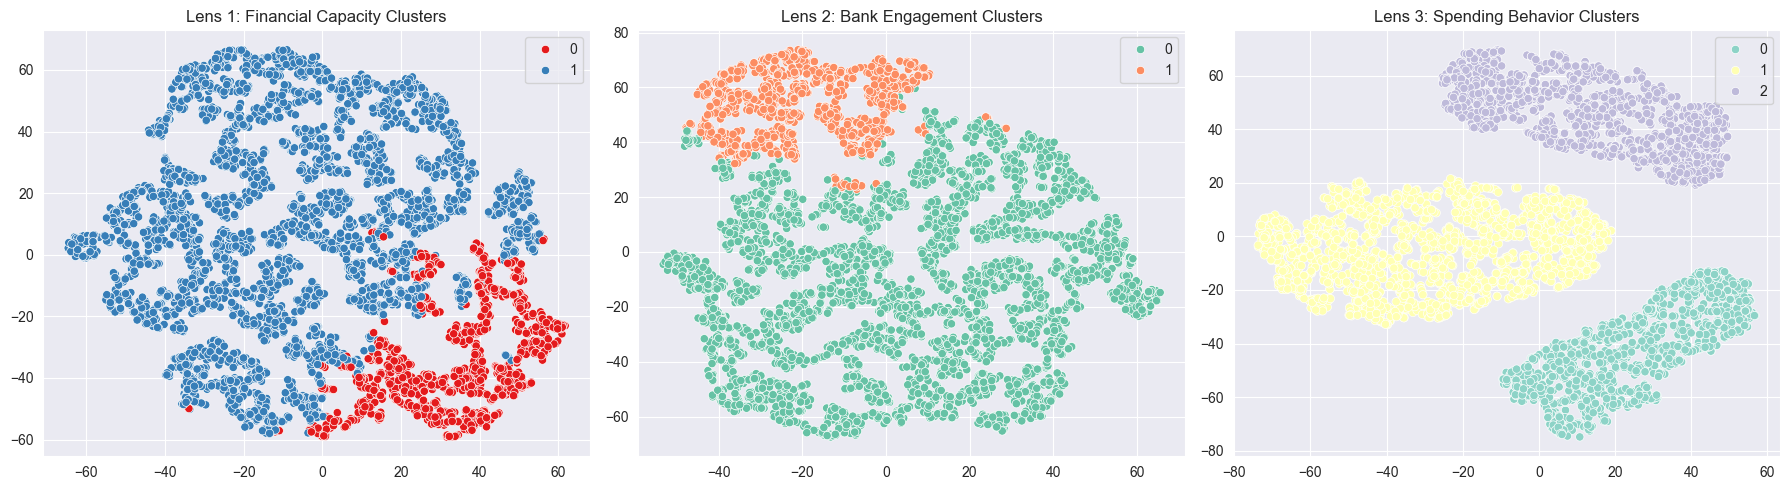

Calculating Global t-SNE...


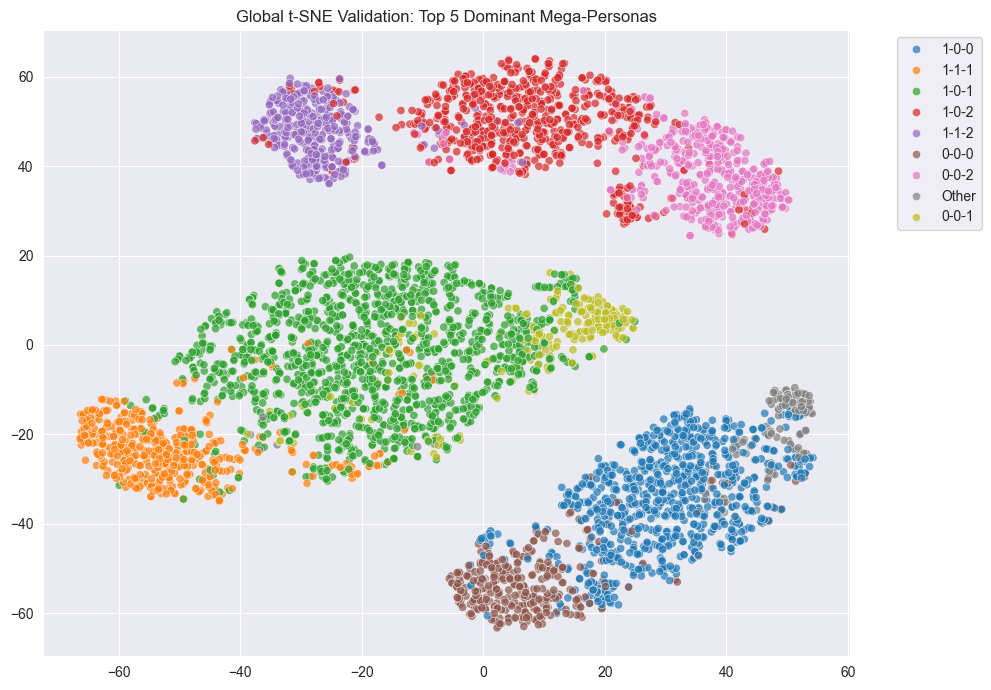

In [7]:
print("Generating visualizations... (t-SNE might take a minute to calculate)")

# VALIDATION: t-SNE PLOTS FOR EACH LENS
tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42)
tsne_lens1 = tsne.fit_transform(dist_mat_lens1)
tsne_lens2 = tsne.fit_transform(dist_mat_lens2)
tsne_lens3 = tsne.fit_transform(dist_mat_lens3)

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=tsne_lens1[:, 0], y=tsne_lens1[:, 1], hue=labels_lens1, palette='Set1', ax=axes[0])
axes[0].set_title('Lens 1: Financial Capacity Clusters')
sns.scatterplot(x=tsne_lens2[:, 0], y=tsne_lens2[:, 1], hue=labels_lens2, palette='Set2', ax=axes[1])
axes[1].set_title('Lens 2: Bank Engagement Clusters')
sns.scatterplot(x=tsne_lens3[:, 0], y=tsne_lens3[:, 1], hue=labels_lens3, palette='Set3', ax=axes[2])
axes[2].set_title('Lens 3: Spending Behavior Clusters')

plt.tight_layout()
plt.show()

# GLOBAL VALIDATION: OVERALL t-SNE
global_distance_matrix = (dist_mat_lens1 + dist_mat_lens2 + dist_mat_lens3) / 3

print("Calculating Global t-SNE...")
tsne_global = TSNE(n_components=2, metric='precomputed', init='random', random_state=42)
tsne_global_coords = tsne_global.fit_transform(global_distance_matrix)

top_personas = persona_counts['Mega_Persona'].head(8).tolist()

df_final['Plot_Label'] = df_final['Mega_Persona'].apply(lambda x: x if x in top_personas else 'Other')

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_global_coords[:, 0],
    y=tsne_global_coords[:, 1],
    hue=df_final['Plot_Label'],
    palette='tab10',
    alpha=0.7
)
plt.title("Global t-SNE Validation: Top 5 Dominant Mega-Personas")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
# THE 3D MATRIX OF MEGA-PERSONAS
# Group by the 3 lenses to get the coordinates and the size (client count) for the bubbles
matrix_df = df_final.groupby(['Lens1_Capacity', 'Lens2_Engagement', 'Lens3_Behavior']).size().reset_index(name='Client_Count')
matrix_df['Mega_Persona'] = matrix_df['Lens1_Capacity'].astype(str) + "-" + matrix_df['Lens2_Engagement'].astype(str) + "-" + matrix_df['Lens3_Behavior'].astype(str)

# Create an interactive 3D Bubble Chart using Plotly
fig_3d = px.scatter_3d(
    matrix_df,
    x='Lens1_Capacity',
    y='Lens2_Engagement',
    z='Lens3_Behavior',
    size='Client_Count',       # Bubble size represents the number of clients
    color='Mega_Persona',      # Different color for each persona combination
    hover_name='Mega_Persona',
    title="3D Matrix of Dominant Client Personas",
    labels={
        'Lens1_Capacity': 'Capacity (0, 1, 2)',
        'Lens2_Engagement': 'Engagement (0, 1, 2)',
        'Lens3_Behavior': 'Behavior (0, 1, 2)'
    },
    opacity=0.8
)

# Force the axes to show only whole numbers (0, 1, 2)
fig_3d.update_layout(
    scene = dict(
        xaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1),
        yaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1),
        zaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1),
    )
)
fig_3d.show()

### Create a PERSONA TABLE (DEMOGRAPHIC PROFILING)

In [9]:
# PERSONA TABLE (DEMOGRAPHIC PROFILING) ─────────────────────────────────

CONTINUOUS_DEMO  = ['Age', 'FamilySize']
CATEGORICAL_DEMO = ['Gender', 'Job', 'Area', 'CitySize']

persona_table = Utilities.build_persona_table(
    df_final,
    persona_col="Mega_Persona",
    continuous_cols=CONTINUOUS_DEMO,
    categorical_cols=CATEGORICAL_DEMO,
)
persona_table = persona_table.sort_values("Client_Count", ascending=False)

# CONTINUOUS: mean ± std and median
continuous_profile = (
    df_final
    .groupby("Mega_Persona")[CONTINUOUS_DEMO]
    .agg(['mean', 'median', 'std'])
    .round(2)
)
continuous_profile.columns = ['_'.join(col) for col in continuous_profile.columns]

# ── CATEGORICAL: dominant category + its share %
def dominant_category(series):
    counts = series.value_counts(normalize=True)
    return f"{counts.index[0]} ({counts.iloc[0]:.0%})"

categorical_profile = (
    df_final
    .groupby("Mega_Persona")[CATEGORICAL_DEMO]
    .agg(dominant_category)
)

# ── MERGE & DISPLAY
# Set Mega_Persona as index on persona_table so all three align on the same key
persona_profile = (
    persona_table
    .set_index("Mega_Persona")[["Client_Count"]]
    .join(continuous_profile)
    .join(categorical_profile)
    .sort_values("Client_Count", ascending=False)
)

print("\nPERSONA PROFILE SUMMARY:")
print(persona_profile.to_string())


PERSONA PROFILE SUMMARY:
              Client_Count  Age_mean  Age_median  Age_std  FamilySize_mean  FamilySize_median  FamilySize_std   Gender      Job      Area CitySize
Mega_Persona                                                                                                                                      
1-0-1                 1491     57.81        57.0    22.41             2.71                3.0            1.53  1 (55%)  2 (79%)   1 (72%)  2 (43%)
1-0-0                  841     57.80        57.0    23.32             2.76                3.0            1.51  1 (55%)  2 (77%)   1 (68%)  2 (44%)
1-0-2                  679     59.80        59.0    21.65             2.52                2.0            1.44  1 (57%)  2 (74%)   1 (74%)  2 (42%)
1-1-1                  472     52.67        54.0    14.50             2.19                2.0            1.20  0 (58%)  2 (83%)   1 (83%)  3 (62%)
0-0-2                  462     77.58        80.0    14.81             2.13                2.

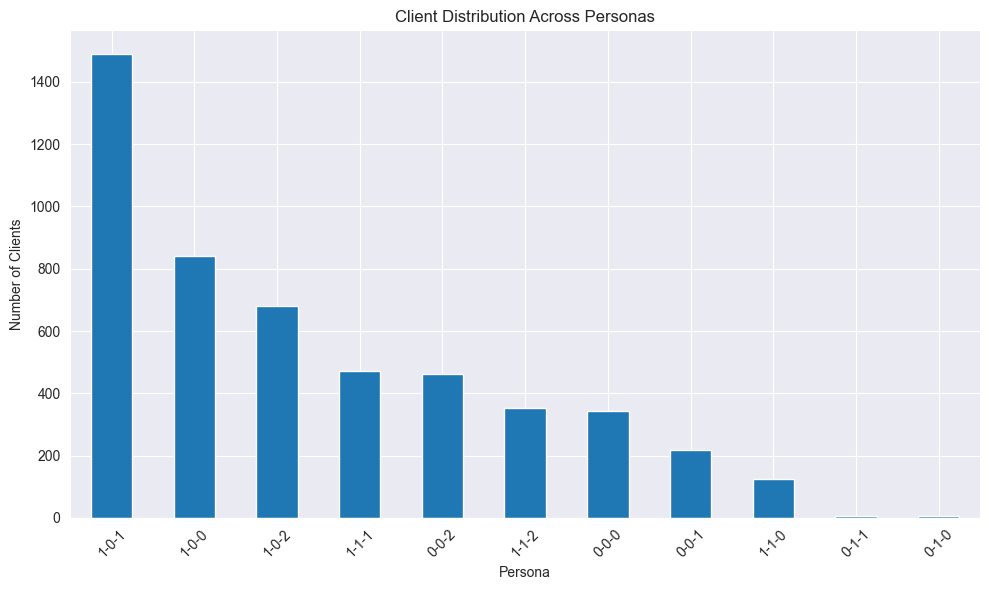

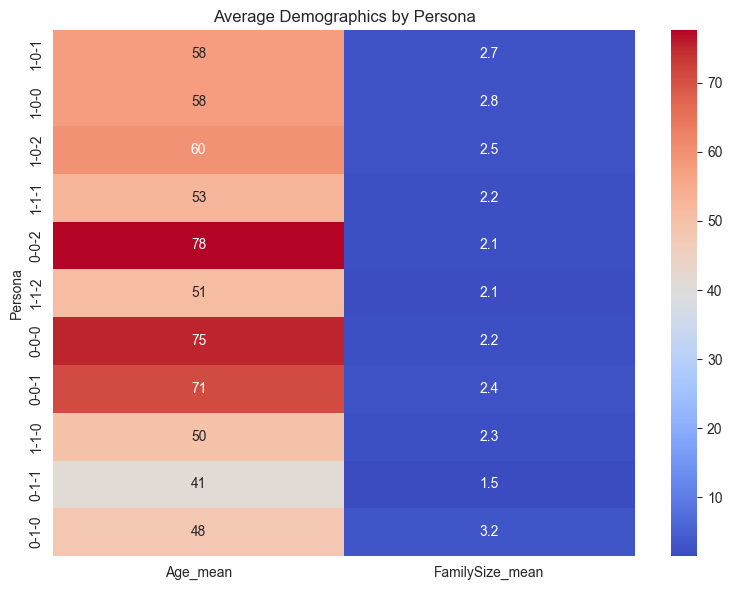

<Figure size 1200x600 with 0 Axes>

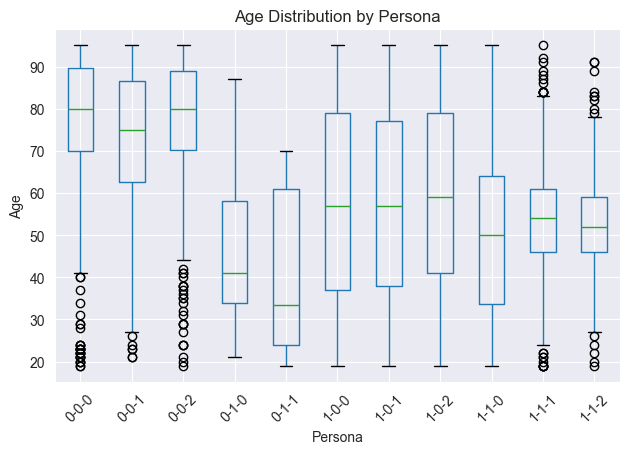

<Figure size 1200x600 with 0 Axes>

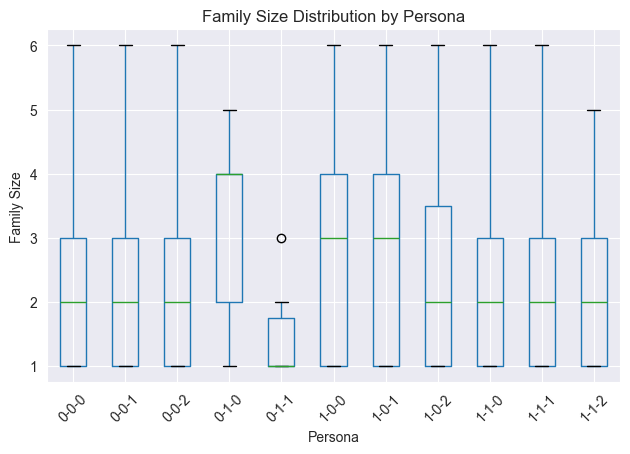

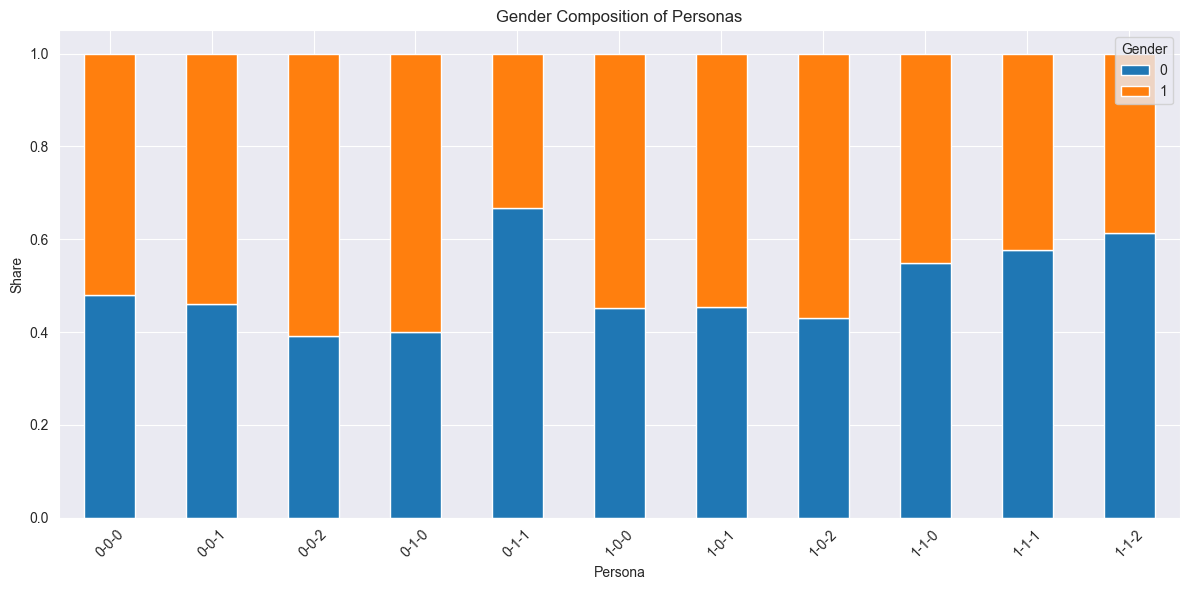

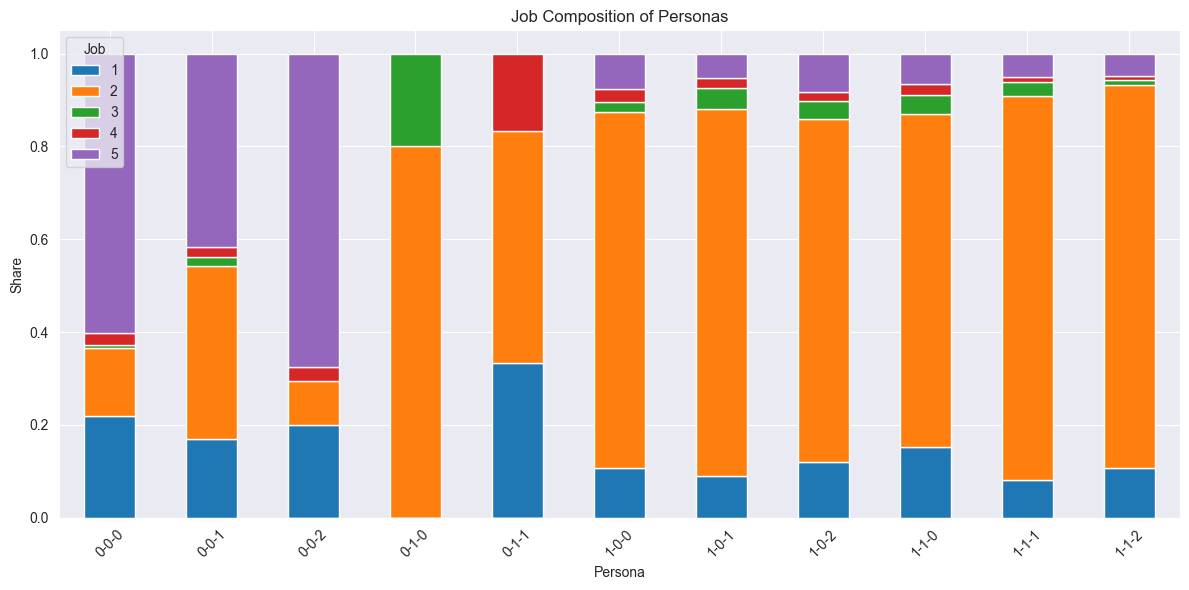

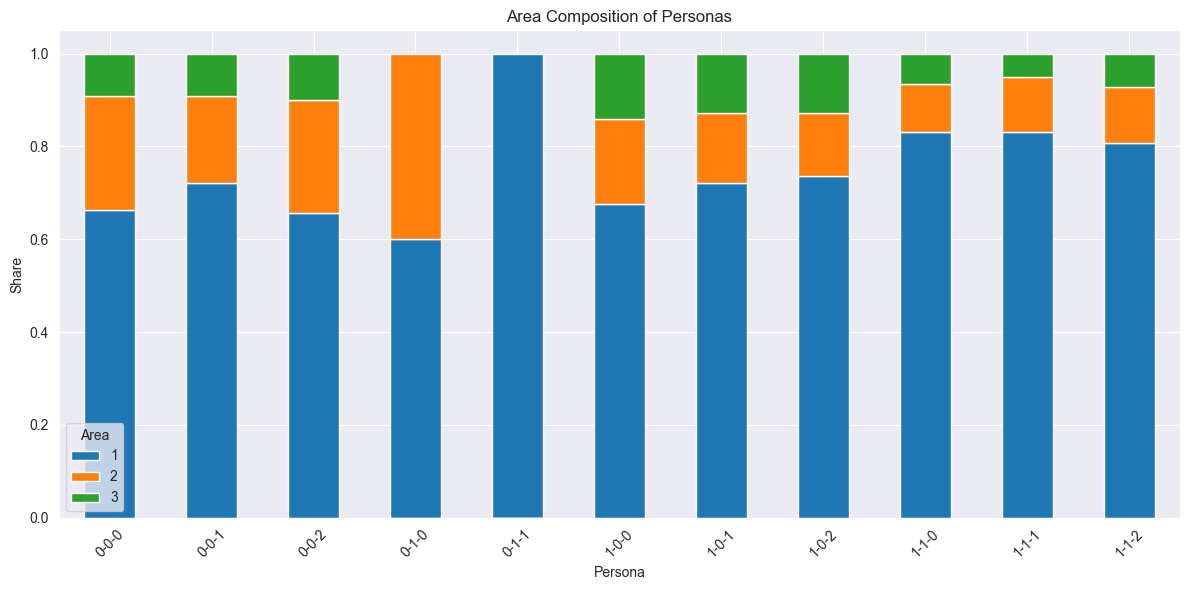

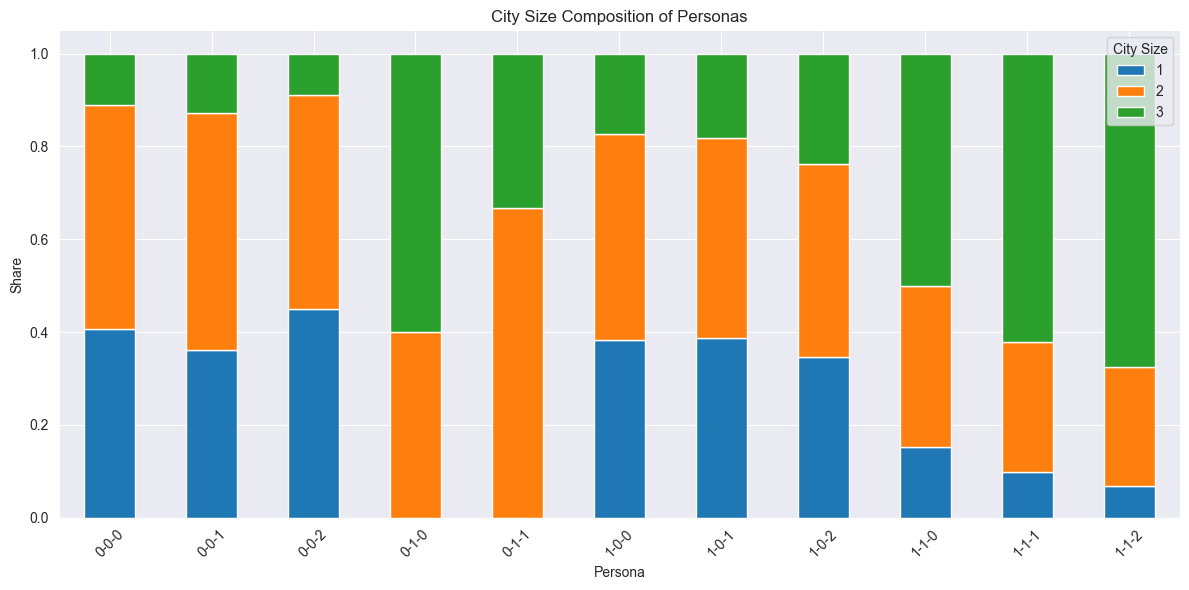

In [10]:
# PERSONA VISUALIZATIONS

fig_size_bar   = (10, 6)
fig_size_box   = (12, 6)
fig_size_stack = (12, 6)

# ── CLIENT COUNT

persona_counts = df_final['Mega_Persona'].value_counts()
plt.figure(figsize=fig_size_bar)
persona_counts.plot(kind='bar')
plt.title("Client Distribution Across Personas")
plt.xlabel("Persona")
plt.ylabel("Number of Clients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── HEATMAP: mean Age & FamilySize ───────────────────────────────────────────

plt.figure(figsize=(8, 6))
sns.heatmap(persona_profile[['Age_mean', 'FamilySize_mean']], annot=True, cmap="coolwarm")
plt.title("Average Demographics by Persona")
plt.ylabel("Persona")
plt.tight_layout()
plt.show()

# BOXPLOTS: continuous demographics

for col, label in [('Age', 'Age'), ('FamilySize', 'Family Size')]:
    plt.figure(figsize=fig_size_box)
    df_final.boxplot(column=col, by='Mega_Persona')
    plt.title(f"{label} Distribution by Persona")
    plt.suptitle("")
    plt.xlabel("Persona")
    plt.ylabel(label)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# STACKED BARS: categorical demographics

for col, label in [
    ('Gender',   'Gender'),
    ('Job',      'Job'),
    ('Area',     'Area'),
    ('CitySize', 'City Size'),
]:
    share = (
        df_final
        .groupby(['Mega_Persona', col])
        .size()
        .unstack()
        .apply(lambda x: x / x.sum(), axis=1)
    )
    share.plot(kind='bar', stacked=True, figsize=fig_size_stack)
    plt.title(f"{label} Composition of Personas")
    plt.xlabel("Persona")
    plt.ylabel("Share")
    plt.xticks(rotation=45)
    plt.legend(title=label)
    plt.tight_layout()
    plt.show()